# C vs Rust perf Comparison for Batch 64

This notebook compares these four files:

- `c_batch064_perf.csv`
- `c_batch064_perf.data`
- `rust_batch064_perf.csv`
- `rust_batch064_perf.data`

It focuses on the `perf stat` differences between C and Rust, and it also attempts to show sampled hotspot output from `perf record` via `perf report --stdio` when the `.data` files are readable.

In [1]:
from pathlib import Path
import math
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)
plt.style.use("seaborn-v0_8-whitegrid")

ROOT = Path("/users/manvik12/my_ice")
C_CSV = ROOT / "c_batch064_perf.csv"
RUST_CSV = ROOT / "rust_batch064_perf.csv"
C_DATA = ROOT / "c_batch064_perf.data"
RUST_DATA = ROOT / "rust_batch064_perf.data"

print(f"C CSV    : {C_CSV}")
print(f"Rust CSV : {RUST_CSV}")
print(f"C data   : {C_DATA}")
print(f"Rust data: {RUST_DATA}")

C CSV    : /users/manvik12/my_ice/c_batch064_perf.csv
Rust CSV : /users/manvik12/my_ice/rust_batch064_perf.csv
C data   : /users/manvik12/my_ice/c_batch064_perf.data
Rust data: /users/manvik12/my_ice/rust_batch064_perf.data


In [2]:
def parse_perf_csv(path: Path, implementation: str) -> pd.DataFrame:
    rows = []
    for raw_line in path.read_text(errors="replace").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#"):
            continue

        parts = line.split(";")
        value_raw = parts[0] if len(parts) > 0 else ""
        unit = parts[1] if len(parts) > 1 else ""
        event = parts[2] if len(parts) > 2 else ""
        counter_runtime = parts[3] if len(parts) > 3 else ""
        running_pct = parts[4] if len(parts) > 4 else ""
        metric_value = parts[5] if len(parts) > 5 else ""
        metric_unit = ";".join(parts[6:]) if len(parts) > 6 else ""

        if not event:
            continue

        status = "ok"
        if value_raw.startswith("<"):
            status = value_raw
            value = np.nan
        else:
            value = pd.to_numeric(value_raw, errors="coerce")

        rows.append({
            "implementation": implementation,
            "event": event,
            "status": status,
            "value_raw": value_raw,
            "value": value,
            "unit": unit,
            "counter_runtime": pd.to_numeric(counter_runtime, errors="coerce"),
            "running_pct": pd.to_numeric(running_pct, errors="coerce"),
            "metric_value": pd.to_numeric(metric_value, errors="coerce"),
            "metric_unit": metric_unit,
        })

    return pd.DataFrame(rows)

def perf_report_excerpt(path: Path, limit: int = 20) -> tuple[str, str]:
    if not path.exists():
        return "missing", f"File not found: {path}"

    try:
        result = subprocess.run(
            ["perf", "report", "--stdio", "--percent-limit", "0.5", "-i", str(path)],
            capture_output=True,
            text=True,
            check=False,
            timeout=60,
        )
    except Exception as exc:
        return "error", str(exc)

    if result.returncode != 0:
        stderr = result.stderr.strip() or result.stdout.strip()
        return "error", stderr

    interesting = []
    for line in result.stdout.splitlines():
        if line.strip().startswith("#"):
            continue
        if "%" in line and ("[.]" in line or "[k]" in line or "=>" in line):
            interesting.append(line.rstrip())
        if len(interesting) >= limit:
            break

    if not interesting:
        interesting = result.stdout.splitlines()[:limit]
    return "ok", "\n".join(interesting)

c_df = parse_perf_csv(C_CSV, "C")
rust_df = parse_perf_csv(RUST_CSV, "Rust")
perf_df = pd.concat([c_df, rust_df], ignore_index=True)

c_report_status, c_report_text = perf_report_excerpt(C_DATA)
rust_report_status, rust_report_text = perf_report_excerpt(RUST_DATA)

In [3]:
file_table = pd.DataFrame([
    {"file": C_CSV.name, "exists": C_CSV.exists(), "size_bytes": C_CSV.stat().st_size if C_CSV.exists() else np.nan},
    {"file": C_DATA.name, "exists": C_DATA.exists(), "size_bytes": C_DATA.stat().st_size if C_DATA.exists() else np.nan},
    {"file": RUST_CSV.name, "exists": RUST_CSV.exists(), "size_bytes": RUST_CSV.stat().st_size if RUST_CSV.exists() else np.nan},
    {"file": RUST_DATA.name, "exists": RUST_DATA.exists(), "size_bytes": RUST_DATA.stat().st_size if RUST_DATA.exists() else np.nan},
])

display(Markdown("## Input Files"))
display(file_table.style.format({"size_bytes": "{:,.0f}"}))

## Input Files

,file,exists,size_bytes
0,c_batch064_perf.csv,True,916
1,c_batch064_perf.data,True,"1,178,808"
2,rust_batch064_perf.csv,True,923
3,rust_batch064_perf.data,True,"760,576"


In [4]:
display(Markdown("## Raw perf stat Rows"))
display(
    perf_df[["implementation", "event", "status", "value_raw", "value", "running_pct", "metric_value", "metric_unit"]]
    .style.format({
        "value": "{:,.0f}",
        "running_pct": "{:.2f}",
        "metric_value": "{:.2f}",
    })
)

## Raw perf stat Rows

,implementation,event,status,value_raw,value,running_pct,metric_value,metric_unit
0,C,instructions,ok,52564427357,"52,564,427,357",57.27,1.76,insn per cycle
1,C,cycles,ok,29907296028,"29,907,296,028",64.39,nan,
2,C,stalled-cycles-frontend,,,nan,100.00,nan,
3,C,stalled-cycles-backend,,,nan,100.00,nan,
4,C,L1-dcache-load-misses,ok,99170606,"99,170,606",64.39,nan,
5,C,L1-icache-load-misses,ok,523976,"523,976",63.88,nan,
6,C,LLC-load-misses,ok,4423,"4,423",49.76,nan,
7,C,LLC-stores,ok,1324176,"1,324,176",49.80,nan,
8,C,LLC-store-misses,ok,7,7,14.24,nan,
9,C,L1-dcache-prefetches,,,nan,100.00,nan,


In [5]:
pivot_value = perf_df.pivot(index="event", columns="implementation", values="value")
pivot_status = perf_df.pivot(index="event", columns="implementation", values="status")
pivot_running = perf_df.pivot(index="event", columns="implementation", values="running_pct")
pivot_metric = perf_df.pivot(index="event", columns="implementation", values="metric_value")

comparison = pd.DataFrame(index=sorted(perf_df["event"].unique()))
comparison["C_value"] = pivot_value.get("C")
comparison["Rust_value"] = pivot_value.get("Rust")
comparison["C_status"] = pivot_status.get("C")
comparison["Rust_status"] = pivot_status.get("Rust")
comparison["C_running_pct"] = pivot_running.get("C")
comparison["Rust_running_pct"] = pivot_running.get("Rust")
comparison["C_metric"] = pivot_metric.get("C")
comparison["Rust_metric"] = pivot_metric.get("Rust")
comparison["Rust_over_C"] = comparison["Rust_value"] / comparison["C_value"]
comparison["Abs_diff"] = comparison["Rust_value"] - comparison["C_value"]

display(Markdown("## Side-by-Side C vs Rust Comparison"))
display(
    comparison.style.format({
        "C_value": "{:,.0f}",
        "Rust_value": "{:,.0f}",
        "C_running_pct": "{:.2f}",
        "Rust_running_pct": "{:.2f}",
        "C_metric": "{:.2f}",
        "Rust_metric": "{:.2f}",
        "Rust_over_C": "{:.2f}x",
        "Abs_diff": "{:,.0f}",
    })
)

## Side-by-Side C vs Rust Comparison

,C_value,Rust_value,C_status,Rust_status,C_running_pct,Rust_running_pct,C_metric,Rust_metric,Rust_over_C,Abs_diff
L1-dcache-load-misses,"99,170,606","53,495,817",ok,ok,64.39,64.40,nan,nan,0.54x,"-45,674,789"
L1-dcache-prefetches,nan,nan,,,100.00,100.00,nan,nan,nanx,nan
L1-icache-load-misses,"523,976","623,478",ok,ok,63.88,63.91,nan,nan,1.19x,"99,502"
LLC-load-misses,"4,423","10,844",ok,ok,49.76,49.79,nan,nan,2.45x,"6,421"
LLC-store-misses,7,63,ok,ok,14.24,14.24,nan,nan,9.00x,56
LLC-stores,"1,324,176","21,488,050",ok,ok,49.80,49.82,nan,nan,16.23x,"20,163,874"
branch-misses,"1,313,481","20,648,592",ok,ok,43.16,43.13,0.02,0.18,15.72x,"19,335,111"
branches,"8,221,986,542","11,641,241,087",ok,ok,36.08,36.06,nan,nan,1.42x,"3,419,254,545"
bus-cycles,"20,947,925,064","20,953,652,942",ok,ok,50.16,50.14,nan,nan,1.00x,"5,727,878"
cpu-migrations,0,0,ok,ok,100.00,100.00,nan,nan,nanx,0


In [6]:
summary = pd.DataFrame([
    {
        "implementation": "C",
        "instructions": c_df.loc[c_df["event"] == "instructions", "value"].squeeze(),
        "cycles": c_df.loc[c_df["event"] == "cycles", "value"].squeeze(),
        "ipc": c_df.loc[c_df["event"] == "instructions", "metric_value"].squeeze(),
        "branch_misses": c_df.loc[c_df["event"] == "branch-misses", "value"].squeeze(),
        "branch_miss_rate": c_df.loc[c_df["event"] == "branch-misses", "metric_value"].squeeze(),
        "l1d_misses": c_df.loc[c_df["event"] == "L1-dcache-load-misses", "value"].squeeze(),
        "l1i_misses": c_df.loc[c_df["event"] == "L1-icache-load-misses", "value"].squeeze(),
        "llc_load_misses": c_df.loc[c_df["event"] == "LLC-load-misses", "value"].squeeze(),
        "dtlb_misses": c_df.loc[c_df["event"] == "dTLB-load-misses", "value"].squeeze(),
        "itlb_misses": c_df.loc[c_df["event"] == "iTLB-load-misses", "value"].squeeze(),
    },
    {
        "implementation": "Rust",
        "instructions": rust_df.loc[rust_df["event"] == "instructions", "value"].squeeze(),
        "cycles": rust_df.loc[rust_df["event"] == "cycles", "value"].squeeze(),
        "ipc": rust_df.loc[rust_df["event"] == "instructions", "metric_value"].squeeze(),
        "branch_misses": rust_df.loc[rust_df["event"] == "branch-misses", "value"].squeeze(),
        "branch_miss_rate": rust_df.loc[rust_df["event"] == "branch-misses", "metric_value"].squeeze(),
        "l1d_misses": rust_df.loc[rust_df["event"] == "L1-dcache-load-misses", "value"].squeeze(),
        "l1i_misses": rust_df.loc[rust_df["event"] == "L1-icache-load-misses", "value"].squeeze(),
        "llc_load_misses": rust_df.loc[rust_df["event"] == "LLC-load-misses", "value"].squeeze(),
        "dtlb_misses": rust_df.loc[rust_df["event"] == "dTLB-load-misses", "value"].squeeze(),
        "itlb_misses": rust_df.loc[rust_df["event"] == "iTLB-load-misses", "value"].squeeze(),
    },
])

display(Markdown("## High-Level Summary"))
display(summary.style.format({
    "instructions": "{:,.0f}",
    "cycles": "{:,.0f}",
    "ipc": "{:.2f}",
    "branch_misses": "{:,.0f}",
    "branch_miss_rate": "{:.2f}",
    "l1d_misses": "{:,.0f}",
    "l1i_misses": "{:,.0f}",
    "llc_load_misses": "{:,.0f}",
    "dtlb_misses": "{:,.0f}",
    "itlb_misses": "{:,.0f}",
}))

## High-Level Summary

,implementation,instructions,cycles,ipc,branch_misses,branch_miss_rate,l1d_misses,l1i_misses,llc_load_misses,dtlb_misses,itlb_misses
0,C,"52,564,427,357","29,907,296,028",1.76,"1,313,481",0.02,"99,170,606","523,976","4,423",18,"372,556"
1,Rust,"67,987,815,861","29,916,348,995",2.27,"20,648,592",0.18,"53,495,817","623,478","10,844",276,"258,713"


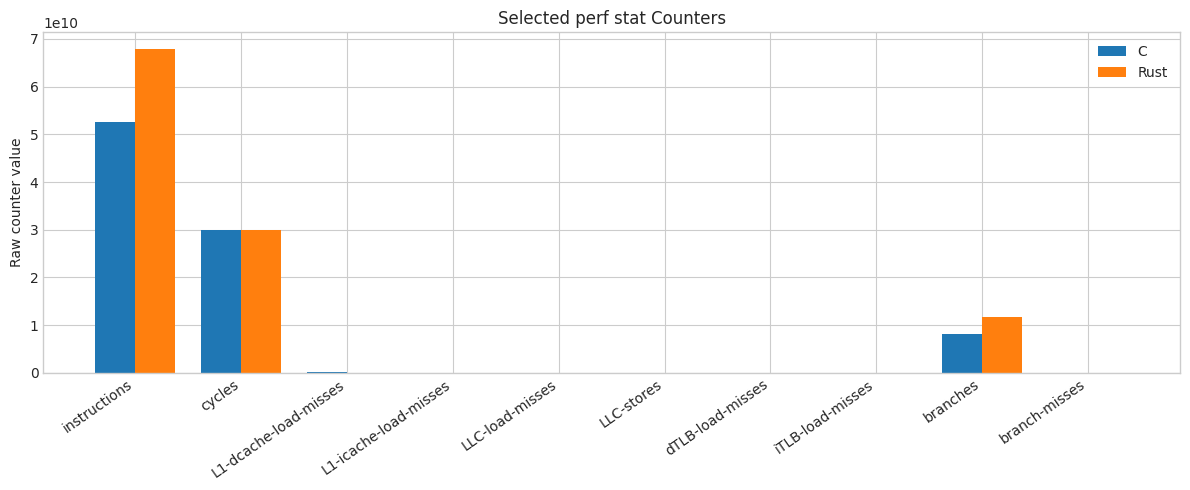

In [7]:
plot_events = [
    "instructions",
    "cycles",
    "L1-dcache-load-misses",
    "L1-icache-load-misses",
    "LLC-load-misses",
    "LLC-stores",
    "dTLB-load-misses",
    "iTLB-load-misses",
    "branches",
    "branch-misses",
]
plot_df = perf_df[(perf_df["event"].isin(plot_events)) & (perf_df["status"] == "ok")].copy()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(plot_events))
width = 0.38

c_vals = [plot_df.loc[(plot_df["implementation"] == "C") & (plot_df["event"] == event), "value"].squeeze() for event in plot_events]
r_vals = [plot_df.loc[(plot_df["implementation"] == "Rust") & (plot_df["event"] == event), "value"].squeeze() for event in plot_events]

ax.bar(x - width / 2, c_vals, width, label="C")
ax.bar(x + width / 2, r_vals, width, label="Rust")
ax.set_xticks(x)
ax.set_xticklabels(plot_events, rotation=35, ha="right")
ax.set_ylabel("Raw counter value")
ax.set_title("Selected perf stat Counters")
ax.legend()
plt.tight_layout()
plt.show()

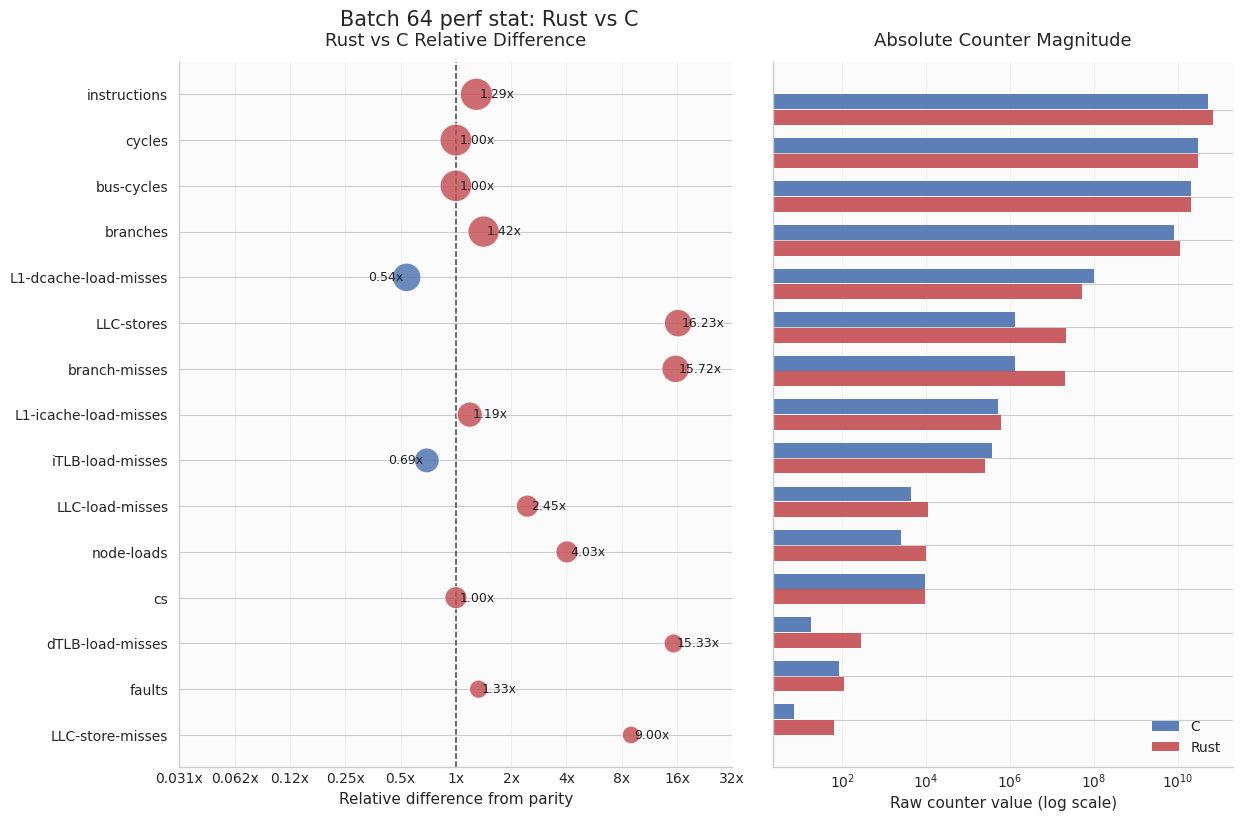

### How To Read This Plot
- Left: each point shows the **relative Rust/C difference**. The center line is parity. Right of center means Rust is higher; left means Rust is lower.
- Left: the labels show the exact Rust/C ratio, while the bubble size reflects the **absolute counter magnitude** so tiny events like `7 vs 63` do not dominate visually.
- Right: the same events are shown with their **raw values on a log scale**, which makes it easier to see whether a large ratio comes from a tiny counter or a major one.

In [ ]:
    better_df = comparison.loc[comparison[["C_value", "Rust_value"]].notna().all(axis=1)].copy()
    better_df = better_df[(better_df["C_value"] > 0) & (better_df["Rust_value"] > 0)].copy()
    better_df["Rust_over_C"] = better_df["Rust_value"] / better_df["C_value"]
    better_df = better_df[np.isfinite(better_df["Rust_over_C"])]
    better_df["log2_ratio"] = np.log2(better_df["Rust_over_C"])
    better_df["max_value"] = better_df[["C_value", "Rust_value"]].max(axis=1)
    better_df["importance"] = np.log10(better_df["max_value"] + 1)
    better_df = better_df.sort_values("max_value", ascending=False)

    fig_height = max(7, 0.42 * len(better_df) + 1.8)
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15.5, fig_height),
        gridspec_kw={"width_ratios": [1.2, 1], "wspace": 0.08},
    )

    for ax in axes:
        ax.set_facecolor("#fbfbfc")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    y = np.arange(len(better_df))
    colors = np.where(better_df["log2_ratio"] >= 0, "#c44e52", "#4c72b0")
    sizes = 90 + 42 * better_df["importance"]
    ratio_limit = max(0.6, float(np.ceil(np.abs(better_df["log2_ratio"]).max() * 1.15 * 2) / 2))

    axes[0].scatter(
        better_df["log2_ratio"],
        y,
        s=sizes,
        c=colors,
        alpha=0.82,
        edgecolors="white",
        linewidths=0.9,
        zorder=3,
    )
    axes[0].axvline(0.0, color="#444444", linestyle="--", linewidth=1.1, zorder=1)
    axes[0].set_xlim(-ratio_limit, ratio_limit)
    tick_positions = np.arange(math.floor(-ratio_limit), math.ceil(ratio_limit) + 1)
    axes[0].set_xticks(tick_positions)
    axes[0].set_xticklabels([f"{2.0**tick:.2g}x" if tick != 0 else "1x" for tick in tick_positions])

    axes[0].set_yticks(y)
    axes[0].set_yticklabels(better_df.index, fontsize=10)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Relative difference from parity", fontsize=11)
    axes[0].set_title("Rust vs C Relative Difference", fontsize=13, pad=12)
    axes[0].grid(True, axis="x", alpha=0.22, zorder=0)
    axes[0].tick_params(axis="y", length=0, pad=8)

    for yi, (_, row) in enumerate(better_df.iterrows()):
        axes[0].text(
            row["log2_ratio"] + (0.06 if row["log2_ratio"] >= 0 else -0.06),
            yi,
            f"{row['Rust_over_C']:.2f}x",
            va="center",
            ha="left" if row["log2_ratio"] >= 0 else "right",
            fontsize=9,
            color="#222222",
        )

    axes[1].barh(y - 0.18, better_df["C_value"], height=0.34, label="C", color="#4c72b0", alpha=0.90)
    axes[1].barh(y + 0.18, better_df["Rust_value"], height=0.34, label="Rust", color="#c44e52", alpha=0.90)
    axes[1].set_yticks(y)
    axes[1].set_yticklabels([])
    axes[1].invert_yaxis()
    axes[1].set_xscale("log")
    axes[1].set_xlabel("Raw counter value (log scale)", fontsize=11)
    axes[1].set_title("Absolute Counter Magnitude", fontsize=13, pad=12)
    axes[1].grid(True, axis="x", alpha=0.22)
    axes[1].legend(frameon=False, loc="lower right")

    fig.suptitle("Batch 64 perf stat: Rust vs C", fontsize=15, y=0.995)
    fig.subplots_adjust(left=0.30, right=0.98, top=0.93, bottom=0.06)
    plt.show()

    display(Markdown(
        "### How To Read This Plot\n"
        "- Left: each point shows the **relative Rust/C difference**. The center line is parity. Right of center means Rust is higher; left means Rust is lower.\n"
        "- Left: the labels show the exact Rust/C ratio, while the bubble size reflects the **absolute counter magnitude** so tiny events like `7 vs 63` do not dominate visually.\n"
        "- Right: the same events are shown with their **raw values on a log scale**, which makes it easier to see whether a large ratio comes from a tiny counter or a major one."
    ))

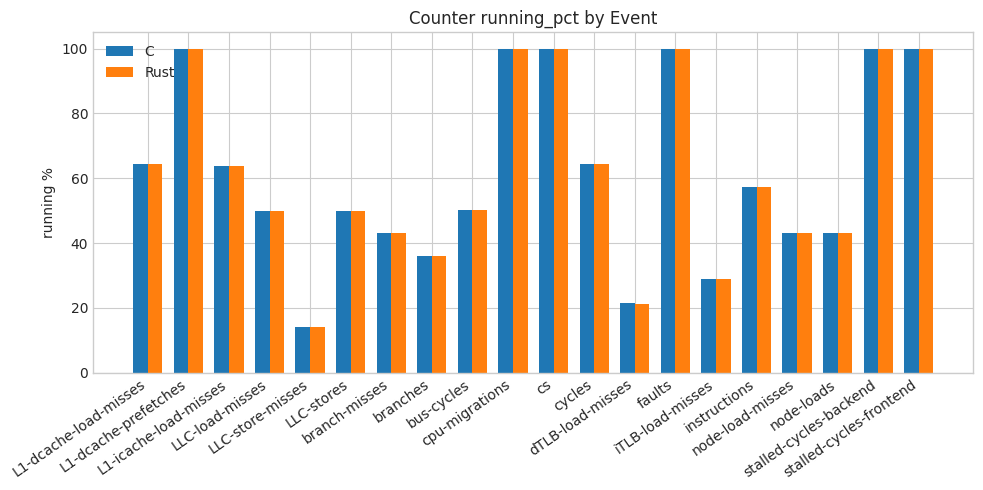

In [9]:
running_df = comparison.loc[:, ["C_running_pct", "Rust_running_pct"]].dropna(how="all")
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(running_df.index))
ax.bar(x - 0.18, running_df["C_running_pct"].fillna(0), width=0.36, label="C")
ax.bar(x + 0.18, running_df["Rust_running_pct"].fillna(0), width=0.36, label="Rust")
ax.set_xticks(x)
ax.set_xticklabels(running_df.index, rotation=35, ha="right")
ax.set_ylabel("running %")
ax.set_title("Counter running_pct by Event")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
display(Markdown("## perf record Hotspot Excerpts"))

if c_report_status == "ok":
    display(Markdown(f"### C hotspot excerpt\n```text\n{c_report_text}\n```"))
else:
    display(Markdown(f"### C hotspot excerpt\nCould not read `c_batch064_perf.data`: `{c_report_text}`"))

if rust_report_status == "ok":
    display(Markdown(f"### Rust hotspot excerpt\n```text\n{rust_report_text}\n```"))
else:
    display(Markdown(f"### Rust hotspot excerpt\nCould not read `rust_batch064_perf.data`: `{rust_report_text}`"))

## perf record Hotspot Excerpts

### C hotspot excerpt
Could not read `c_batch064_perf.data`: `failed to open /users/manvik12/my_ice/c_batch064_perf.data: Permission denied`

### Rust hotspot excerpt
Could not read `rust_batch064_perf.data`: `failed to open /users/manvik12/my_ice/rust_batch064_perf.data: Permission denied`

In [11]:
notes = [
    "- `instructions`: Rust retired noticeably more instructions than C in this run.",
    "- `cycles`: total cycles are nearly identical, so the instruction delta shows up as a higher IPC for Rust.",
    "- `branch-misses`: Rust is much higher here; the branch miss metric is one of the clearest C vs Rust differences in these files.",
    "- `L1-dcache-load-misses`: Rust is lower than C here, so not every memory-side signal is worse.",
    "- `LLC-stores`, `dTLB-load-misses`, and `node-loads`: Rust is substantially higher on these counters in this single comparison.",
    "- Events with low `running_pct` or statuses like `<not counted>` / `<not supported>` should be interpreted carefully; those are not strong apples-to-apples signals.",
]
display(Markdown("## Quick Reading Guide\n" + "\n".join(notes)))

## Quick Reading Guide
- `instructions`: Rust retired noticeably more instructions than C in this run.
- `cycles`: total cycles are nearly identical, so the instruction delta shows up as a higher IPC for Rust.
- `branch-misses`: Rust is much higher here; the branch miss metric is one of the clearest C vs Rust differences in these files.
- `L1-dcache-load-misses`: Rust is lower than C here, so not every memory-side signal is worse.
- `LLC-stores`, `dTLB-load-misses`, and `node-loads`: Rust is substantially higher on these counters in this single comparison.
- Events with low `running_pct` or statuses like `<not counted>` / `<not supported>` should be interpreted carefully; those are not strong apples-to-apples signals.

In [12]:
RESULTS_ROOT = ROOT / "results" / "reflect_perf_compare"
SUMMARY_CSV = sorted(RESULTS_ROOT.glob("*/summary.csv"))[-1] if RESULTS_ROOT.exists() and list(RESULTS_ROOT.glob("*/summary.csv")) else None

# If you have the exact transmitted-packet totals for these standalone perf files,
# put them here and rerun the normalization section below.
MANUAL_PACKET_COUNTS = {
    "C": np.nan,
    "Rust": np.nan,
}

NORM_SPECS = {
    "instructions": {"label": "Instructions / pkt", "scale": "per_pkt"},
    "cycles": {"label": "Cycles / pkt", "scale": "per_pkt"},
    "branches": {"label": "Branches / pkt", "scale": "per_pkt"},
    "branch-misses": {"label": "Branch misses / Mpkt", "scale": "per_mpkt"},
    "L1-dcache-load-misses": {"label": "L1D misses / Mpkt", "scale": "per_mpkt"},
    "L1-icache-load-misses": {"label": "L1I misses / Mpkt", "scale": "per_mpkt"},
    "LLC-load-misses": {"label": "LLC load misses / Mpkt", "scale": "per_mpkt"},
    "LLC-stores": {"label": "LLC stores / Mpkt", "scale": "per_mpkt"},
    "LLC-store-misses": {"label": "LLC store misses / Mpkt", "scale": "per_mpkt"},
    "dTLB-load-misses": {"label": "dTLB misses / Mpkt", "scale": "per_mpkt"},
    "iTLB-load-misses": {"label": "iTLB misses / Mpkt", "scale": "per_mpkt"},
    "node-loads": {"label": "NUMA loads / Mpkt", "scale": "per_mpkt"},
    "faults": {"label": "Faults / Mpkt", "scale": "per_mpkt"},
    "cs": {"label": "Context switches / Mpkt", "scale": "per_mpkt"},
    "cpu-migrations": {"label": "CPU migrations / Mpkt", "scale": "per_mpkt"},
}


def load_summary_csv(path: Path | None) -> pd.DataFrame:
    if path is None or not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    for col in df.columns:
        if col not in {"timestamp_utc", "implementation", "run_id", "status", "bdf", "hugepage_dir", "stdout_log", "stderr_log", "perf_file"}:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def event_value(frame: pd.DataFrame, event: str) -> float:
    series = frame.loc[frame["event"] == event, "value"]
    return series.squeeze() if not series.empty else np.nan


def resolve_tx_pkts(implementation: str, perf_frame: pd.DataFrame, summary_df: pd.DataFrame) -> tuple[float, str]:
    manual = MANUAL_PACKET_COUNTS.get(implementation)
    if pd.notna(manual) and manual > 0:
        return float(manual), "manual_override"

    if summary_df.empty:
        return np.nan, "missing_summary_csv"

    impl_key = implementation.lower()
    candidates = summary_df[summary_df["implementation"] == impl_key].copy()
    if candidates.empty:
        return np.nan, "implementation_not_in_summary"

    instructions = event_value(perf_frame, "instructions")
    cycles = event_value(perf_frame, "cycles")
    branch_misses = event_value(perf_frame, "branch-misses")

    fingerprint = candidates["perf_instructions"].eq(instructions) & candidates["perf_cycles"].eq(cycles)
    if pd.notna(branch_misses) and "perf_branch_misses" in candidates.columns:
        fingerprint &= candidates["perf_branch_misses"].eq(branch_misses)

    matches = candidates.loc[fingerprint & candidates["tx_pkts"].fillna(0).gt(0)].copy()
    if len(matches) == 1:
        row = matches.iloc[0]
        return float(row["tx_pkts"]), f"summary_match:{row['run_id']}"
    if len(matches) > 1:
        unique_tx = matches["tx_pkts"].dropna().unique()
        if len(unique_tx) == 1:
            run_ids = ",".join(matches["run_id"].astype(str))
            return float(unique_tx[0]), f"summary_match_multi:{run_ids}"
        return np.nan, "ambiguous_matching_runs"

    return np.nan, "no_matching_tx_pkts"


def normalize_event(value: float, tx_pkts: float, scale: str) -> float:
    if pd.isna(value) or pd.isna(tx_pkts) or tx_pkts <= 0:
        return np.nan
    if scale == "per_pkt":
        return value / tx_pkts
    if scale == "per_mpkt":
        return 1e6 * value / tx_pkts
    raise ValueError(scale)


summary_df = load_summary_csv(SUMMARY_CSV)
packet_rows = []
normalized_rows = []

for implementation, frame in [("C", c_df), ("Rust", rust_df)]:
    tx_pkts, tx_source = resolve_tx_pkts(implementation, frame, summary_df)
    packet_rows.append({
        "implementation": implementation,
        "tx_pkts": tx_pkts,
        "tx_pkts_source": tx_source,
        "summary_csv": str(SUMMARY_CSV) if SUMMARY_CSV else "",
    })

    for event, spec in NORM_SPECS.items():
        raw_value = event_value(frame, event)
        normalized_rows.append({
            "implementation": implementation,
            "event": event,
            "metric": spec["label"],
            "raw_value": raw_value,
            "normalized_value": normalize_event(raw_value, tx_pkts, spec["scale"]),
        })

packet_info = pd.DataFrame(packet_rows)
normalized_long = pd.DataFrame(normalized_rows)
normalized_comparison = normalized_long.pivot(index="metric", columns="implementation", values="normalized_value")
normalized_comparison = normalized_comparison.reindex([spec["label"] for spec in NORM_SPECS.values()]).dropna(how="all")
normalized_comparison["Rust / C"] = normalized_comparison["Rust"] / normalized_comparison["C"]


In [13]:
display(Markdown("## Packet Count Resolution"))
display(packet_info.style.format({"tx_pkts": "{:,.0f}"}))

missing_tx = packet_info["tx_pkts"].isna().any()
if missing_tx:
    display(Markdown(
        "Per-packet normalization needs the matching `tx_pkts` total for each perf capture. "
        "This notebook now tries `MANUAL_PACKET_COUNTS` first and then looks for an exact fingerprint match in the latest `results/reflect_perf_compare/*/summary.csv`. "
        "For the current standalone root CSVs, no exact packet-count match was found in this workspace."
    ))
else:
    display(Markdown("Packet counts were resolved, so the normalized tables and plots below are apples-to-apples per transmitted packet."))


display(Markdown("## Normalized Counter Comparison"))
display(
    normalized_comparison.style.format({
        "C": "{:.3f}",
        "Rust": "{:.3f}",
        "Rust / C": "{:.2f}x",
    })
)


## Packet Count Resolution

,implementation,tx_pkts,tx_pkts_source,summary_csv
0,C,nan,no_matching_tx_pkts,/users/manvik12/my_ice/results/reflect_perf_compare/20260507_195825/summary.csv
1,Rust,nan,no_matching_tx_pkts,/users/manvik12/my_ice/results/reflect_perf_compare/20260507_195825/summary.csv


Per-packet normalization needs the matching `tx_pkts` total for each perf capture. This notebook now tries `MANUAL_PACKET_COUNTS` first and then looks for an exact fingerprint match in the latest `results/reflect_perf_compare/*/summary.csv`. For the current standalone root CSVs, no exact packet-count match was found in this workspace.

## Normalized Counter Comparison

implementation,C,Rust,Rust / C
metric,,,


In [14]:
normalized_plot_order = [
    "Instructions / pkt",
    "Cycles / pkt",
    "Branches / pkt",
    "Branch misses / Mpkt",
    "L1D misses / Mpkt",
    "L1I misses / Mpkt",
    "LLC load misses / Mpkt",
    "LLC stores / Mpkt",
    "dTLB misses / Mpkt",
    "iTLB misses / Mpkt",
]

plot_df = normalized_comparison.reindex(normalized_plot_order).dropna(how="all")

if plot_df[["C", "Rust"]].notna().any().any():
    fig, ax = plt.subplots(figsize=(13, 5.5))
    x = np.arange(len(plot_df.index))
    width = 0.38

    ax.bar(x - width / 2, plot_df["C"].fillna(0), width=width, label="C", color="#4c72b0")
    ax.bar(x + width / 2, plot_df["Rust"].fillna(0), width=width, label="Rust", color="#c44e52")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=30, ha="right")
    ax.set_ylabel("Normalized counter value")
    ax.set_title("Batch 64 perf counters normalized by transmitted packets")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    ratio_df = plot_df[(plot_df["C"] > 0) & (plot_df["Rust"] > 0)].copy()
    ratio_df["Rust / C"] = ratio_df["Rust"] / ratio_df["C"]
    ratio_df = ratio_df.sort_values("Rust / C", ascending=False)

    fig, ax = plt.subplots(figsize=(9, max(4, 0.42 * len(ratio_df) + 1.2)))
    y = np.arange(len(ratio_df.index))
    colors = np.where(ratio_df["Rust / C"] >= 1.0, "#c44e52", "#4c72b0")
    ax.barh(y, ratio_df["Rust / C"], color=colors, alpha=0.9)
    ax.axvline(1.0, color="#444444", linestyle="--", linewidth=1.0)
    ax.set_yticks(y)
    ax.set_yticklabels(ratio_df.index)
    ax.invert_yaxis()
    ax.set_xlabel("Rust / C")
    ax.set_title("Normalized metric ratios")
    for yi, value in enumerate(ratio_df["Rust / C"]):
        ax.text(value + 0.03, yi, f"{value:.2f}x", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown(
        "No normalized plot yet because `tx_pkts` could not be resolved for these exact perf captures. "
        "If you still have the matching app summary or know the packet totals, fill `MANUAL_PACKET_COUNTS` and rerun this section only."
    ))


No normalized plot yet because `tx_pkts` could not be resolved for these exact perf captures. If you still have the matching app summary or know the packet totals, fill `MANUAL_PACKET_COUNTS` and rerun this section only.

In [15]:
def lookup_metric(metric: str, implementation: str) -> float:
    row = normalized_long[(normalized_long["metric"] == metric) & (normalized_long["implementation"] == implementation)]
    return row["normalized_value"].squeeze() if not row.empty else np.nan

notes = []
if packet_info["tx_pkts"].notna().all():
    c_cycles = lookup_metric("Cycles / pkt", "C")
    r_cycles = lookup_metric("Cycles / pkt", "Rust")
    c_instr = lookup_metric("Instructions / pkt", "C")
    r_instr = lookup_metric("Instructions / pkt", "Rust")
    c_br = lookup_metric("Branches / pkt", "C")
    r_br = lookup_metric("Branches / pkt", "Rust")
    c_bm = lookup_metric("Branch misses / Mpkt", "C")
    r_bm = lookup_metric("Branch misses / Mpkt", "Rust")

    notes.append(f"- C is at **{c_cycles:.1f} cycles/pkt** and Rust is at **{r_cycles:.1f} cycles/pkt**.")
    notes.append(f"- C is at **{c_instr:.1f} instructions/pkt** and Rust is at **{r_instr:.1f} instructions/pkt**.")
    notes.append(f"- C is at **{c_br:.1f} branches/pkt** and Rust is at **{r_br:.1f} branches/pkt**.")
    notes.append(f"- Branch misses land at **{c_bm:.1f} / Mpkt** for C versus **{r_bm:.1f} / Mpkt** for Rust.")
else:
    notes.append("- The normalization logic is now in the notebook, but these exact standalone perf files still need matching `tx_pkts` totals before the per-packet numbers can be trusted.")
    notes.append("- If you have the original app output, paste the packet totals into `MANUAL_PACKET_COUNTS` and rerun just the normalization section at the bottom.")
    notes.append("- If those totals are gone, then yes, you would need to rerun the experiment to get exact per-packet numbers for these files.")

notes.append("- Raw counter views are still preserved above; the new section only adds normalized tables and linear-scale plots.")

display(Markdown("## Normalized Reading Guide\n" + "\n".join(notes)))


## Normalized Reading Guide
- The normalization logic is now in the notebook, but these exact standalone perf files still need matching `tx_pkts` totals before the per-packet numbers can be trusted.
- If you have the original app output, paste the packet totals into `MANUAL_PACKET_COUNTS` and rerun just the normalization section at the bottom.
- If those totals are gone, then yes, you would need to rerun the experiment to get exact per-packet numbers for these files.
- Raw counter views are still preserved above; the new section only adds normalized tables and linear-scale plots.